# Pre processing

Le data pre processing est l'une des étapes les plus importantes d'un data pour déveloper des modèles avec de bonnes performances.


Les modèles de machine learning apprennent à partir de données qui leurs sont fourni.

Il faut donc faire attention aux données que nous lui fournissons, donc il faudra limiter les données erronnée, incomplète, redondante, ... si non l'algorithme qui en résulte sera assez mauvais.

Il faudra donc bien nettoyer, filter, normaliser les données.

Nous avons donc plusieurs grandes catégories de pre-processing :
- l'encodage : qui convertira des données qualitative en valeurs numérique
- la normalisation : qui mettera sur une même échelle toutes les valeurs quantitative, ce qui facilitera l'apprentissage de la machine.
- l'imputation : qui remplacera les données manquantes par des valeurs statistique.
- la sélection : qui utilisera des testes statistique pour sélectionner les variables les plus pertinantes.
- l'extraction : qui permettera de généré de nouvelles variables à partir d'informations cachée dans le dataset.

Pour le preprocessing nous avons différents modules dans SKLearn : 
- sklearn.preprocessing pour l'encodage et la normalisation
- sklearn.impute pour les imputations
- sklearn.feature_selection pour la sélection
- sklearn.feature_extraction pour l'extraction

Dans le module preprocessing on retrouve deux type : 
- des classes de transformations reconnaissable par le nom commencant par une majuscule.
- des routines mathématique, des fonctions et procédures simple.

Ceux qui nous intéresseront le plus sont les Transformer, donc les class de transformation.

L'avantage des Transformer, c'est qu'on pourra les réutiliser sur les données futur pour effectuer les même transformations que sur nos données initiales.

Les Transformer vont avoir deux méthodes importantes : 
- La methode fit(X) : qui générer les transformations sur le train set.
- la methode transform : qui va refaire les même transformations sur les futurs données.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

In [2]:
X = np.array(['Chat', 'Oiseau', 'Chien', 'Chat', 'Lapin'])

transformer = LabelEncoder()
transformer.fit(X)

LabelEncoder()

In [3]:
transformer.transform(X)

array([0, 3, 1, 0, 2])

fit_transform combine les deux fonction vue au dessus.

In [4]:
transformer.fit_transform(X)

array([0, 3, 1, 0, 2])

Lorsque nous combinons un transformer avec un estimator (model) nous obtenons ce que l'on appel une pipeline, ou une chaine de transformation.

# Encodage Ordinal

Lors du dévelopment d'un modèle de machine learning il est nécéssaire de fournir à la machine des données qu'elle peut comprendre et comparer, donc des valeurs numérique.

Il est donc indispensable de convertir les string et objets en valeurs numérique.

Il existe plusieurs modules d'encodage : 
- preprocessing.LabelBinarizer
- preprocessing.LabelEncore
- preprocessing.MultiLabelBinarizer
- preprocessing.OneHotEncoder
- preprocessing.OrdinalEncoder

Ces encodeur permettent d'executer deux type d'encodage : 

L'encodage Ordinal et l'encodage One-Hot

L'encodage Ordinal va associé chaque valeur qualitative à une valeur numérique unique.

Par exemple :
- Chat -> 0
- Chien -> 1
- Oiseau -> 2
- Lapin -> 3

Pour faire celà nous avons deux Transformer à notre disposition : 
- LabelEncoder
- OrdinalEncoder

Le LabelEncoder a été spécifiquement fait pour traiter la variable y, il est donc prévu pour ne traiter qu'une seule colonne.



In [5]:
X = np.array(['Chat', 'Oiseau', 'Chien', 'Chat', 'Lapin'])

transformer = LabelEncoder()
transformer.fit(X)
transformer.transform(X)

array([0, 3, 1, 0, 2])

Nous avons aussi la fonction inverse_transform qui nous permet d'inversé la transformation :

In [6]:
y = transformer.transform(X)
y

array([0, 3, 1, 0, 2])

In [7]:
transformer.inverse_transform(y)

array(['Chat', 'Oiseau', 'Chien', 'Chat', 'Lapin'], dtype='<U6')

Maintenant comme dit précédement, le LabelEncoder ne fonctionne pas sur des tables avec plus d'une colonne :

In [8]:
# X = np.array([['Chat', 'Félin'], 
#             ['Oiseau', 'Aviens'], 
#             ['Chien', 'Canidé'], 
#             ['Chat', 'Félin'], 
#             ['Lapin', 'Léoporiés']])
# 
# transformer = LabelEncoder()
# transformer.fit(X)
# transformer.transform(X)

In [9]:
from sklearn.preprocessing import OrdinalEncoder

In [10]:
X = np.array([['Chat', 'Félin'], 
            ['Oiseau', 'Aviens'], 
            ['Chien', 'Canidé'], 
            ['Chat', 'Félin'], 
            ['Lapin', 'Léoporidés']])

transformer = OrdinalEncoder()
transformer.fit(X)
transformer.transform(X)

array([[0., 2.],
       [3., 0.],
       [1., 1.],
       [0., 2.],
       [2., 3.]])

Le soucis de cette méthode, est qu'elle revient à dire qu'un chat < Chien < Oiseau (0 < 1 < 3), ce qui n'a évidement aucun sense.

Cela peut poser des risques, pour les modèles basé sur l'ordre des données qu'on leur présent, donc presques tous les modèles en dehors des arbres de décision.

# Encodage One-Hot

C'est exactement pour palier à ce problème que l'encodage One Hot a été mis en place.

L'encodage OneHot va créer une matrice qui ne contiendra que des 1 ou des 0.

On va donc représenter chaque classe de façon binaire dans une colonne qui lui est propre.

Pour ce faire on dispose de trois transformers dans SKLearn : 
- LabelBinarizer
- MultiLabelBinarizer
- OneHotEncoder



In [11]:
from sklearn.preprocessing import LabelBinarizer

In [12]:
X = np.array(['Chat', 'Oiseau', 'Chien', 'Chat', 'Lapin'])

transformer = LabelBinarizer()
transformer.fit(X)
transformer.transform(X)

array([[1, 0, 0, 0],
       [0, 0, 0, 1],
       [0, 1, 0, 0],
       [1, 0, 0, 0],
       [0, 0, 1, 0]])

# Sparse Matrix

Comme vous pouvez le voir ce type de transformations pose elle aussi des problèmes.

Au lieu d'avoir une colonne représentant les valeurs d'une colonne on aura n colonne ou n est le nombre de valeur possible par colonne.

Le soucis est qu'il y aura principalement des valeurs inutile dans notre matrice, car elle sera principalement remplie de 0.

Cette matrice va donc prendre une certaine taille occupé une certaine taille en mémoire, ce qui peut poser problème lors de l'utilisation de dataset particulièrement grand.

On a donc une solution à ce problème, ce qu'on appel une Sparse Matrix. Étant donné que notre matrice est principalement remplie de 0, on peut la compresser facilement et c'est exactement ce que va faire la sparse matrix.

Au lieu d'avoir une matrice contenant des 1 et 0 on aura trois tableau :
- un tableau qui contiendra les valeurs
- un tableau qui contiendra l'indice des lignes
- un tableau qui contiendra l'indice des colonnes

values = [1, 1, 1]

rows = [0,1,3]

cols = [0,2,4]

Ce format s'appel le format Coordinate ou COO pour les intimes. Ce n'est pas exactement celui qui est utilisé dans SKLearn qui sera le CSR pour Compressed Sparse Row qui est un format plus compressé mais qui ressemble fort au format vu précédement.

On peut donc choisir si l'on veut une output compressé ou non avec le LabelBinarizer :

In [13]:
X = np.array(['Chat', 'Oiseau', 'Chien', 'Chat', 'Lapin'])

transformer = LabelBinarizer(sparse_output=True) # compressera la sortie
transformer.fit(X)
transformer.transform(X)

<5x4 sparse matrix of type '<class 'numpy.int64'>'
	with 5 stored elements in Compressed Sparse Row format>

Pour le transformer OneHotEncoder il s'agit d'ailleur du choix par défaut :

In [14]:
from sklearn.preprocessing import OneHotEncoder

In [15]:
X = np.array([['Chat', 'Félin'], 
            ['Oiseau', 'Aviens'], 
            ['Chien', 'Canidé'], 
            ['Chat', 'Félin'], 
            ['Lapin', 'Léoporidés']])

transformer = OneHotEncoder()
transformer.fit(X)
transformer.transform(X)

<5x8 sparse matrix of type '<class 'numpy.float64'>'
	with 10 stored elements in Compressed Sparse Row format>

Le One Hot encoder s'attend aussi à recevoir un tableau 2D, si on a qu'une seule dimension il faudra utiliser le LabelBinarizer.

## Avertissement 

Attention les encoder ne fonctionneront pas si on leur passe des valeurs différentes de celles passées dans le trainset. Il faudra donc faire particulièrement attention avec ceux-ci pour être sûr que tous les labels possible se trouvent dans le test set.

C'est une des raison pour lesquels beaucoup de datascientist vont créer eux même leur propre fonctions d'encodage.

# Normalisation MinMax

En datascience il est indispensable de normaliser les données, c'est à dire de les mettre toutes sur une même échelle.

Celà facilitera considérablement l'apprentissage des modèles de machine learning basé sur la descente de gradiant, les calculs de distance ou encore les calculs de variance.

Sans la normalisation, dans le cas d'une descente de gradiant. Celà rendra la tache de la fonction cout plus difficile, car elle aura du mal à converger vers son minimum.

![caption](Normalize.png)

Nous allons commencer par voir la normalisation MinMaxScaler :

Celle-ci va simplement faire en sorte que chaque valeur de X soit comprise en 0 et 1.

X = (X - Xmin) / (Xmax - Xmin)

In [16]:
from sklearn.preprocessing import MinMaxScaler

In [17]:
X = np.array([[70], [80], [120], [75], [82]])
scaler = MinMaxScaler()
scaler.fit_transform(X)

array([[0.  ],
       [0.2 ],
       [1.  ],
       [0.1 ],
       [0.24]])

On pourrais se dire qu'il y a de la perte d'information, et que notre modèle risque de ne plus comprendre correctement nos données, mais en réalité ce n'est pas le cas.

Ici notre normalisation a bien gardé les rapports de distance entre nos valeurs, mais au lieux de les faire varier de 0 à n, elle les fait varier de 0 à 1.

In [18]:
X_test = np.array([[85]])
scaler.transform(X_test)

array([[0.3]])

Maintenant voyons un exemple concret en utilisant le dataset des fleurs d'iris :

In [19]:
from sklearn.datasets import load_iris

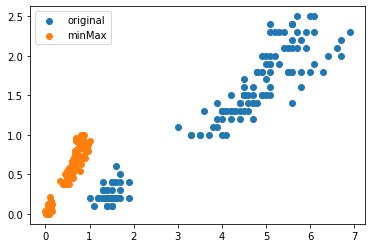

In [20]:
iris = load_iris()
X = iris.data

scaler = MinMaxScaler()
X_minMax = scaler.fit_transform(X)

plt.scatter(X[:, 2], X[:, 3], label='original')
plt.scatter(X_minMax[:, 2], X_minMax[:, 3], label='minMax')
plt.legend()
plt.show()

# Standardisation

La standardisation va faire en sorte que la moyenne soit égal à 0 et que l'écart type soit écale à 1.

In [21]:
from sklearn.preprocessing import StandardScaler

In [22]:
X_base = np.array([[70], [80], [120], [75], [82]])
scaler = StandardScaler()
scaler.fit_transform(X_base)

array([[-0.86544173],
       [-0.30346658],
       [ 1.94443402],
       [-0.58445416],
       [-0.19107155]])

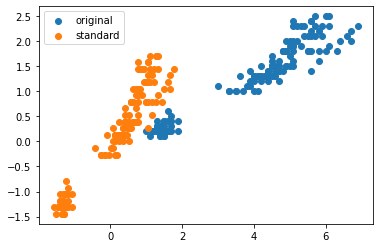

In [23]:
X_stdscl = StandardScaler().fit_transform(X)

plt.scatter(X[:, 2], X[:, 3], label='original')
plt.scatter(X_stdscl[:, 2], X_stdscl[:, 3], label='standard')
plt.legend()
plt.show()

La technique de standardisation et de MinMax sont très bonne, mais on un défaut, qui est celui d'être sensible aux outliers (valeurs abérantes dans notre dataset).

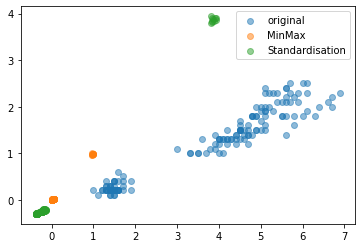

In [24]:
outliers = np.full((10, 4), 100) + np.random.randn(10, 4)
X_outliers = np.vstack((X, outliers))

X_o_minMax = MinMaxScaler().fit_transform(X_outliers)
X_o_stdscl = StandardScaler().fit_transform(X_outliers)

plt.scatter(X[:, 2], X[:, 3], alpha=0.5, label='original')
plt.scatter(X_o_minMax[:, 2], X_o_minMax[:, 3], alpha=0.5, label='MinMax')
plt.scatter(X_o_stdscl[:, 2], X_o_stdscl[:, 3], alpha=0.5, label='Standardisation')
plt.legend()
plt.show()

Ici on voit que les données du MinMaxScaler et du StandardScaler se sont faites écraser par les outliers.

Ce sera donc beaucoup plus difficile à utiliser par notre modèle.

# RobustScaler

C'est pour cette raison qu'on a le RobustScaler.

Ici au lieu d'utiliser la moyenne on va utiliser la médiane et l'interquartile (l'écart entre le premier quartile et le 3ème quartile): 

Xscaled = (X - mediane) / IQR 

In [25]:
from sklearn.preprocessing import RobustScaler

In [26]:
X_base = np.array([[70], [80], [120], [75], [82]])
scaler = RobustScaler()
scaler.fit_transform(X_base)

array([[-1.42857143],
       [ 0.        ],
       [ 5.71428571],
       [-0.71428571],
       [ 0.28571429]])

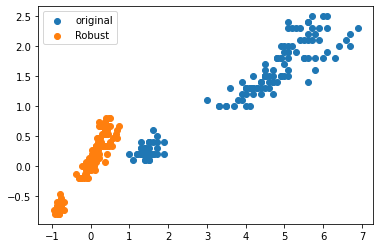

In [27]:

X_robust = RobustScaler().fit_transform(X)

plt.scatter(X[:, 2], X[:, 3], label='original')
plt.scatter(X_robust[:, 2], X_robust[:, 3], label='Robust')
plt.legend()
plt.show()

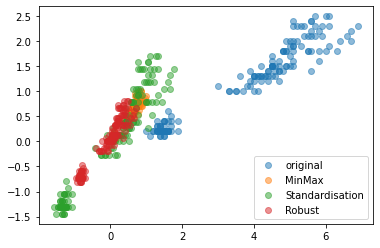

In [28]:
plt.scatter(X[:, 2], X[:, 3], alpha=0.5, label='original')
plt.scatter(X_minMax[:, 2], X_minMax[:, 3], alpha=0.5, label='MinMax')
plt.scatter(X_stdscl[:, 2], X_stdscl[:, 3], alpha=0.5, label='Standardisation')
plt.scatter(X_robust[:, 2], X_robust[:, 3], alpha=0.5, label='Robust')
plt.legend()
plt.show()

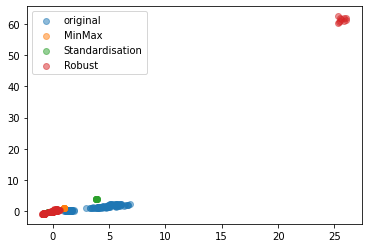

In [29]:
X_o_rbscl = RobustScaler().fit_transform(X_outliers)

plt.scatter(X[:, 2], X[:, 3], alpha=0.5, label='original')
plt.scatter(X_o_minMax[:, 2], X_o_minMax[:, 3], alpha=0.5, label='MinMax')
plt.scatter(X_o_stdscl[:, 2], X_o_stdscl[:, 3], alpha=0.5, label='Standardisation')
plt.scatter(X_o_rbscl[:, 2], X_o_rbscl[:, 3], alpha=0.5, label='Robust')
plt.legend()
plt.show()

On peut donc voir ici que le robust scaler est beaucoup moins sensible aux outliers et a donc données nettement moins compressée et toujours exploitable.

# PolynominalFeatures

Crée une variable dite polynomiale à partir de variable existantes.

C'est ce qu'on appel faire du feature engineering. 

Le polynomiale transformer va créer n nouvelle colonne à partir des variables données.

Par exemple dans le cas d'un transformer polynomiale de degré 2, il va nous crée au total 3 colonnes à partir de notre colonne d'origine.

Dans le cas du degré 2 il va nous créer une colonne de biais qui contiendra des valeurs égale à 1, ensuite une colonne x qui contiendra la valeur de x et une colonne x² qui contiendra x².

Dans le cas d'un modèle polynomiale de degré 2, notre machine va donc apprendre le modèle suivant : 
- f(x)  = ax² + bx + c

ce qui nous permettera de créer des modèles bien plus sophistiqué.

In [30]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

In [31]:
X = np.array([[1], [2], [0.5]])
PolynomialFeatures(3).fit_transform(X)

array([[1.   , 1.   , 1.   , 1.   ],
       [1.   , 2.   , 4.   , 8.   ],
       [1.   , 0.5  , 0.25 , 0.125]])

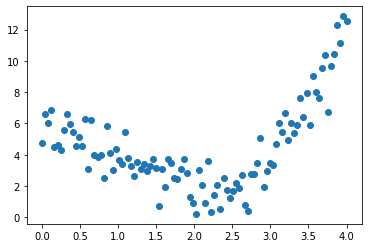

In [32]:
X = np.linspace(0, 4, 100).reshape((100, 1))
y = X**2 + 5*np.cos(X) + np.random.randn(100, 1)
plt.scatter(X, y)

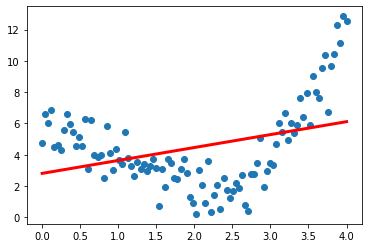

In [33]:
model = LinearRegression().fit(X, y)
y_pred = model.predict(X)

plt.scatter(X, y)
plt.plot(X, y_pred, c='r',lw=3)

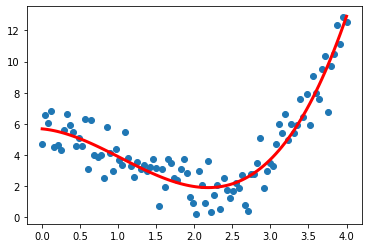

In [34]:
X_poly = PolynomialFeatures(3).fit_transform(X)

model = LinearRegression().fit(X_poly, y)
y_pred = model.predict(X_poly)

plt.scatter(X, y)
plt.plot(X, y_pred, c='r',lw=3)

Sur un vrais dataset, le polynomiale feature peut être utile pour combiner plusieurs paramêtre de notre dataset, par exemple la surface d'une maison avec son nombre de pièces.

Attention, il ne faut pas oublier de normaliser ces données après avoir utiliser le polynomiale feature.

# Discretisation

Ici on va découper une variable continue en plusieurs partie. Par exemple plusieurs catégories d'ages (nouveau né, enfant, adolescent, adulte, senior, ...).

Ici nous allons avoir deux transformer : 
- Binarizer : Celui-ci va découper en deux catégorie une variable à partir d'un seuil donné.
- KBinsDiscretizer : Celui-ci nous permettera de faire la même chose que le précédent mais nous permettera de découper les variables en plus de deux groupes.



In [38]:
from sklearn.preprocessing import Binarizer, KBinsDiscretizer

In [39]:
X = np.linspace(0, 5, 10).reshape((10, 1))
X

array([[0.        ],
       [0.55555556],
       [1.11111111],
       [1.66666667],
       [2.22222222],
       [2.77777778],
       [3.33333333],
       [3.88888889],
       [4.44444444],
       [5.        ]])

In [40]:
np.hstack((X, Binarizer(threshold=2).fit_transform(X)))

array([[0.        , 0.        ],
       [0.55555556, 0.        ],
       [1.11111111, 0.        ],
       [1.66666667, 0.        ],
       [2.22222222, 1.        ],
       [2.77777778, 1.        ],
       [3.33333333, 1.        ],
       [3.88888889, 1.        ],
       [4.44444444, 1.        ],
       [5.        , 1.        ]])

In [42]:
KBinsDiscretizer(n_bins=6).fit_transform(X).toarray()

array([[1., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 1.]])